# 🌍 Middle East Economy & Oil Prices Analysis (1990–2024)

Welcome to this comprehensive economic analysis of Middle Eastern countries over the past three decades.  
This notebook explores **GDP, trade, inflation, FDI, unemployment, life expectancy, and oil price impacts**, using clean and visually consistent plots in a light earth-tone theme.

---

## 🔎 Objectives

- Understand **long-term macroeconomic trends** across 13 Middle Eastern economies (1990–2024).
- Investigate how **Brent oil price shocks** relate to:
  - GDP growth
  - Trade (exports/imports)
  - FDI inflows
  - Inflation
  - Unemployment
- Compare **oil-sensitive vs less oil-sensitive economies**.
- Detect **crisis periods and anomalies** (e.g., 1991 Gulf War, 2008 crisis, 2014 crash, 2020 COVID-19 shock).
- Group countries into **clusters** based on economic structure and oil dependency.

---

## 📁 Dataset

- File: `Middle_East_Economic_Data_1990_2024_with_Oil.csv`
- Balanced panel: **13 countries**, **1990–2024**
- Key variables:
  - `Country`, `Country_Code`, `Year`
  - `GDP_current_USD`, `GDP_growth_annual_pct`, `GDP_per_capita_current_USD`
  - `Exports_pct_GDP`, `Imports_pct_GDP`, `Trade_Balance_pct_GDP` (derived)
  - `FDI_net_inflows_pct_GDP`
  - `Inflation_consumer_prices_annual_pct`
  - `Unemployment_total_pct`
  - `Life_expectancy_years`
  - `Brent_Oil_Price_USD_per_barrel`

All analysis below assumes these columns are present and uses **defensive checks** where appropriate.

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Try importing Plotly for interactive visualizations
try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly is not installed. Interactive visualizations will be skipped.")

# Try importing scikit-learn for clustering
try:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("scikit-learn is not installed. Clustering section will be skipped.")

# Pandas display options
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)

# ---------------------------
# 🎨 Light Earth-Tone Theme
# ---------------------------
COLOR_PALETTE = [
    "#2E86AB",  # blue
    "#F6AE2D",  # warm yellow
    "#33673B",  # green
    "#9E2B25",  # deep red
    "#774C60",  # mauve
    "#4E937A",  # teal
    "#B56576",  # rose
]

BACKGROUND_COLOR = "#f7f5f2"
GRID_COLOR = "rgba(0, 0, 0, 0.08)"

# Matplotlib / Seaborn theme
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": BACKGROUND_COLOR,
        "figure.facecolor": BACKGROUND_COLOR,
        "axes.edgecolor": "#e6d0d0",
        "grid.color": "#e6b9b9",
        "axes.labelcolor": "#333333",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "axes.titleweight": "bold",
        "axes.titlecolor": "#222222",
        "figure.autolayout": True,
    },
)
sns.set_palette(COLOR_PALETTE)

# Plotly theme
if PLOTLY_AVAILABLE:
    earth_light_template = go.layout.Template(
        layout=go.Layout(
            paper_bgcolor=BACKGROUND_COLOR,
            plot_bgcolor="#ffffff",
            font=dict(family="Arial", color="#333333"),
            colorway=COLOR_PALETTE,
            xaxis=dict(
                gridcolor=GRID_COLOR,
                zerolinecolor="rgba(0,0,0,0.1)",
                linecolor="rgba(0,0,0,0.3)",
            ),
            yaxis=dict(
                gridcolor=GRID_COLOR,
                zerolinecolor="rgba(0,0,0,0.1)",
                linecolor="rgba(0,0,0,0.3)",
            ),
            legend=dict(
                bgcolor="rgba(255,255,255,0.8)",
                bordercolor="rgba(0,0,0,0.1)",
            ),
        )
    )
    pio.templates["earth_light"] = earth_light_template
    pio.templates.default = "earth_light"

print("Theme and libraries initialized.")

Theme and libraries initialized.


In [2]:
# Path to the CSV file (adjust if needed)
DATA_PATH = "Middle_East_Economic_Data_1990_2024_with_Oil.csv"

df = pd.read_csv(DATA_PATH)

print("Data loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Data loaded successfully.
Shape: (455, 13)
Columns: ['Country', 'Country_Code', 'Year', 'Exports_pct_GDP', 'FDI_net_inflows_pct_GDP', 'GDP_current_USD', 'GDP_growth_annual_pct', 'GDP_per_capita_current_USD', 'Imports_pct_GDP', 'Inflation_consumer_prices_annual_pct', 'Life_expectancy_years', 'Unemployment_total_pct', 'Brent_Oil_Price_USD_per_barrel']


## 📊 1️⃣ Data Overview & Cleaning

In this section we:

- Inspect the **structure and completeness** of the dataset.
- Confirm the **balanced panel structure** (countries × years).
- Standardize **data types** and coerce numeric columns.
- Create a **trade balance** indicator for further analysis.
- Build a **regional aggregate** time series for key indicators.

In [3]:
# Ensure Year is integer
if "Year" in df.columns:
    df["Year"] = df["Year"].astype(int)

# List of expected numeric columns
numeric_cols = [
    "Exports_pct_GDP",
    "FDI_net_inflows_pct_GDP",
    "GDP_current_USD",
    "GDP_growth_annual_pct",
    "GDP_per_capita_current_USD",
    "Imports_pct_GDP",
    "Inflation_consumer_prices_annual_pct",
    "Life_expectancy_years",
    "Unemployment_total_pct",
    "Brent_Oil_Price_USD_per_barrel",
]

# Coerce to numeric where columns exist
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Sort for sanity
if {"Country", "Year"}.issubset(df.columns):
    df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

# Basic panel checks
if "Country" in df.columns and "Year" in df.columns:
    n_countries = df["Country"].nunique()
    year_min, year_max = df["Year"].min(), df["Year"].max()
    print(f"Number of countries: {n_countries}")
    print(f"Year range: {year_min}–{year_max}")

    print("\nYears per country (for panel completeness):")
    panel_check = df.groupby("Country")["Year"].nunique()
    display(panel_check)

# Missing values overview
print("\nMissing values per column:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("Missing_Count"))

# Derived: Trade balance (% of GDP)
if {"Exports_pct_GDP", "Imports_pct_GDP"}.issubset(df.columns):
    df["Trade_Balance_pct_GDP"] = df["Exports_pct_GDP"] - df["Imports_pct_GDP"]
    print("\nDerived column created: Trade_Balance_pct_GDP = Exports_pct_GDP - Imports_pct_GDP")

# Regional (unweighted) averages per year for quick time-series views
numeric_cols_existing = [c for c in numeric_cols if c in df.columns]
df_region = (
    df.groupby("Year")[numeric_cols_existing]
    .mean()
    .reset_index()
    if "Year" in df.columns and len(numeric_cols_existing) > 0
    else None
)

print("\nPreview of the dataset:")
display(df.head())

print("\nSummary statistics of numeric columns:")
display(df[numeric_cols_existing].describe().T)

Number of countries: 13
Year range: 1990–2024

Years per country (for panel completeness):


Country
Bahrain                 35
Egypt                   35
Iran                    35
Iraq                    35
Israel                  35
Jordan                  35
Kuwait                  35
Lebanon                 35
Oman                    35
Qatar                   35
Saudi Arabia            35
United Arab Emirates    35
Yemen                   35
Name: Year, dtype: int64


Missing values per column:


,Missing_Count
Inflation_consumer_prices_annual_pct,60
Imports_pct_GDP,26
Exports_pct_GDP,26
Unemployment_total_pct,14
Life_expectancy_years,13
FDI_net_inflows_pct_GDP,9
GDP_growth_annual_pct,8
GDP_per_capita_current_USD,7
GDP_current_USD,7
Country_Code,0



Derived column created: Trade_Balance_pct_GDP = Exports_pct_GDP - Imports_pct_GDP

Preview of the dataset:


,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel,Trade_Balance_pct_GDP
0,Bahrain,BHR,1990,101.63,1.91,"4,809,511,005.32",4.44,"9,342.54",83.20,0.93,72.59,NaN,23.00,18.43
1,Bahrain,BHR,1991,74.76,11.80,"5,248,911,170.21",11.23,"10,434.13",84.11,0.76,72.67,1.05,20.00,-9.35
2,Bahrain,BHR,1992,74.21,16.08,"5,402,232,446.81",6.69,"10,460.16",85.08,-0.17,72.78,0.97,18.00,-10.87
3,Bahrain,BHR,1993,73.76,-4.65,"5,913,001,063.83",12.87,"11,151.87",71.00,2.54,72.94,0.88,19.00,2.77
4,Bahrain,BHR,1994,71.41,3.29,"6,330,627,925.53",-0.25,"11,629.36",65.07,0.82,73.13,1.01,25.00,6.34



Summary statistics of numeric columns:


,count,mean,std,min,25%,50%,75%,max
Exports_pct_GDP,429.00,43.28,22.15,0.01,26.54,39.66,56.82,106.85
FDI_net_inflows_pct_GDP,446.00,2.42,3.76,-4.65,0.23,1.21,3.75,29.52
GDP_current_USD,448.00,"149,333,329,128.45","193,509,831,739.27","407,796,349.66","23,033,709,267.70","77,967,053,714.93","186,929,552,375.31","1,239,804,533,333.33"
GDP_growth_annual_pct,447.00,4.44,9.19,-64.05,1.80,3.88,6.25,82.81
GDP_per_capita_current_USD,448.00,"17,314.89","19,132.17",22.95,"3,131.29","10,593.99","25,754.91","108,470.39"
Imports_pct_GDP,429.00,40.99,19.12,0.02,27.23,35.25,54.33,125.71
Inflation_consumer_prices_annual_pct,395.00,11.57,37.26,-16.12,1.24,3.30,10.04,448.50
Life_expectancy_years,442.00,73.93,5.54,57.59,70.22,74.58,78.08,83.20
Unemployment_total_pct,441.00,7.07,5.07,0.10,2.19,7.20,10.91,21.44
Brent_Oil_Price_USD_per_barrel,455.00,57.14,26.35,18.00,27.00,60.00,80.00,105.00


## 📈 2️⃣ Country-Level Economic Trends

Here we explore how key indicators evolved over time:

- **GDP growth** trajectories by country.
- **Life expectancy** improvements.
- **Unemployment** and **inflation** dynamics.
- Regional averages vs. individual countries.

We will use a reusable helper function to visualize **time series by country** with an optional **regional average overlay**, all in a consistent light earth-tone style.

In [4]:
def plot_time_series_by_country(
    data: pd.DataFrame,
    y: str,
    title: str,
    yaxis_title: str,
    countries=None,
    include_region_avg: bool = True,
):
    """
    Plot a time series by country, optionally with regional average.
    Works with Plotly if available, otherwise falls back to Matplotlib.
    """
    required_cols = {"Country", "Year", y}
    if not required_cols.issubset(data.columns):
        print(f"Missing required columns for plotting: {required_cols - set(data.columns)}")
        return

    plot_data = data.copy()

    if countries is not None:
        plot_data = plot_data[plot_data["Country"].isin(countries)]

    # Regional average
    if include_region_avg:
        region_avg = (
            plot_data.groupby("Year")[y]
            .mean()
            .reset_index()
            .assign(Country="Region Average")
        )
        plot_data = pd.concat([plot_data, region_avg], ignore_index=True)

    if PLOTLY_AVAILABLE:
        fig = px.line(
            plot_data,
            x="Year",
            y=y,
            color="Country",
            title=title,
            line_group="Country",
            hover_name="Country",
        )
        fig.update_traces(mode="lines+markers")
        fig.update_layout(
            yaxis_title=yaxis_title,
            legend_title="Country",
        )
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        for country, grp in plot_data.groupby("Country"):
            plt.plot(grp["Year"], grp[y], marker="o", label=country, linewidth=1.5)
        plt.title(title)
        plt.xlabel("Year")
        plt.ylabel(yaxis_title)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.show()

print("Time-series plotting helper ready.")

Time-series plotting helper ready.


In [20]:
# GDP growth by country
if "GDP_growth_annual_pct" in df.columns:
    plot_time_series_by_country(
        df,
        y="GDP_growth_annual_pct",
        title="GDP Growth Rate (%) by Country (1990–2024)",
        yaxis_title="GDP Growth (annual %)",
    )

# Life expectancy by country
if "Life_expectancy_years" in df.columns:
    plot_time_series_by_country(
        df,
        y="Life_expectancy_years",
        title="Life Expectancy at Birth (Years) by Country",
        yaxis_title="Life expectancy (years)",
    )

# Unemployment by country
if "Unemployment_total_pct" in df.columns:
    plot_time_series_by_country(
        df,
        y="Unemployment_total_pct",
        title="Unemployment Rate (% of Labor Force) by Country",
        yaxis_title="Unemployment (% of labor force)",
    )

# Inflation by country
if "Inflation_consumer_prices_annual_pct" in df.columns:
    plot_time_series_by_country(
        df,
        y="Inflation_consumer_prices_annual_pct",
        title="Inflation (Consumer Prices, Annual %) by Country",
        yaxis_title="Inflation (annual %)",
    )

## 🛢 3️⃣ Oil Price Impact Analysis

In this section, we examine how **Brent oil price fluctuations** relate to:

- **GDP growth**
- **Exports (% of GDP)**
- **FDI net inflows (% of GDP)**
- **Inflation**
- **Unemployment**

We also highlight major **oil shock years**:

- **1991** – Gulf War  
- **2008** – Global Financial Crisis & oil spike  
- **2014** – Oil price crash  
- **2020** – COVID-19 & oil collapse  

In [21]:
OIL_COL = "Brent_Oil_Price_USD_per_barrel"

# Correlation of each numeric indicator with Brent oil price
if OIL_COL in df.columns and len(numeric_cols_existing) > 0:
    corr_with_oil = df[numeric_cols_existing].corr()[OIL_COL].sort_values(ascending=False)
    print("Correlation of economic indicators with Brent oil price:")
    display(corr_with_oil.to_frame("Correlation_with_Oil"))

def scatter_oil_vs_indicator(data, indicator, title, yaxis_title):
    if OIL_COL not in data.columns or indicator not in data.columns:
        print(f"Columns required for this plot are missing: {OIL_COL}, {indicator}")
        return

    if PLOTLY_AVAILABLE:
        fig = px.scatter(
            data,
            x=OIL_COL,
            y=indicator,
            color="Country" if "Country" in data.columns else None,
            hover_name="Country" if "Country" in data.columns else None,
            title=title,
            opacity=0.7,
        )
        fig.update_layout(
            xaxis_title="Brent Oil Price (USD/barrel)",
            yaxis_title=yaxis_title,
        )
        fig.show()
    else:
        plt.figure(figsize=(8, 6))
        if "Country" in data.columns:
            sns.scatterplot(
                data=data,
                x=OIL_COL,
                y=indicator,
                hue="Country",
                alpha=0.7,
            )
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        else:
            sns.scatterplot(data=data, x=OIL_COL, y=indicator, alpha=0.7)
        plt.title(title)
        plt.xlabel("Brent Oil Price (USD/barrel)")
        plt.ylabel(yaxis_title)
        plt.show()

# Key relationships with oil prices
pairs_to_plot = [
    ("GDP_growth_annual_pct", "GDP Growth (annual %)"),
    ("Exports_pct_GDP", "Exports (% of GDP)"),
    ("FDI_net_inflows_pct_GDP", "FDI net inflows (% of GDP)"),
    ("Inflation_consumer_prices_annual_pct", "Inflation (annual %)"),
    ("Unemployment_total_pct", "Unemployment (% of labor force)"),
]

for col, label in pairs_to_plot:
    if col in df.columns and OIL_COL in df.columns:
        scatter_oil_vs_indicator(
            df,
            indicator=col,
            title=f"Brent Oil Price vs {label}",
            yaxis_title=label,
        )

Correlation of economic indicators with Brent oil price:


,Correlation_with_Oil
Brent_Oil_Price_USD_per_barrel,1.00
Life_expectancy_years,0.40
GDP_current_USD,0.36
GDP_per_capita_current_USD,0.32
Exports_pct_GDP,0.25
FDI_net_inflows_pct_GDP,0.21
Imports_pct_GDP,0.03
Unemployment_total_pct,0.00
GDP_growth_annual_pct,-0.08
Inflation_consumer_prices_annual_pct,-0.13


In [7]:
oil_shock_years = [1991, 2008, 2014, 2020]

if df_region is not None and OIL_COL in df_region.columns:
    if PLOTLY_AVAILABLE:
        fig = px.line(
            df_region,
            x="Year",
            y=OIL_COL,
            title="Brent Oil Price (USD/barrel) with Key Shock Years",
        )
        for year in oil_shock_years:
            fig.add_vline(x=year, line_dash="dash", line_color="#9E2B25", opacity=0.7)
        fig.update_layout(yaxis_title="Brent Oil Price (USD/barrel)")
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        plt.plot(df_region["Year"], df_region[OIL_COL], marker="o", color=COLOR_PALETTE[0])
        for year in oil_shock_years:
            plt.axvline(year, color="#9E2B25", linestyle="--", alpha=0.7)
        plt.title("Brent Oil Price (USD/barrel) with Key Shock Years")
        plt.xlabel("Year")
        plt.ylabel("Brent Oil Price (USD/barrel)")
        plt.show()

## 📈 4️⃣ Export & Import Dependency

Here we explore:

- **Export-led vs import-heavy** economies.
- A simple proxy for **trade balance**:
  - `Trade_Balance_pct_GDP = Exports_pct_GDP - Imports_pct_GDP`
- Which countries are **net exporters** vs **net importers** (on a GDP basis).

In [9]:
if {"Exports_pct_GDP", "Imports_pct_GDP", "Year"}.issubset(df.columns):
    latest_year = df["Year"].max()
    df_latest = df[df["Year"] == latest_year].copy()

    print(f"Exports vs Imports (% of GDP) – Latest year in dataset: {latest_year}")

    if PLOTLY_AVAILABLE:
        # choose size column and drop/fill NaNs to avoid Plotly error
        size_col = "GDP_current_USD" if "GDP_current_USD" in df.columns else None
        df_plot = df_latest.copy()
        if size_col is not None:
            # Plotly rejects NaNs for marker size; replace with 0 (or drop)
            df_plot[size_col] = df_plot[size_col].fillna(0)

        fig = px.scatter(
            df_plot,
            x="Imports_pct_GDP",
            y="Exports_pct_GDP",
            hover_name="Country",
            color="Country",
            size=size_col,
            title=f"Exports vs Imports (% of GDP), {latest_year}",
        )
        fig.update_layout(
            xaxis_title="Imports (% of GDP)",
            yaxis_title="Exports (% of GDP)",
        )
        # 45-degree line (exports = imports)
        min_val = min(df_plot["Imports_pct_GDP"].min(), df_plot["Exports_pct_GDP"].min())
        max_val = max(df_plot["Imports_pct_GDP"].max(), df_plot["Exports_pct_GDP"].max())
        fig.add_shape(
            type="line",
            x0=min_val,
            y0=min_val,
            x1=max_val,
            y1=max_val,
            line=dict(color="#9E2B25", dash="dash"),
        )
        fig.show()
    else:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=df_latest,
            x="Imports_pct_GDP",
            y="Exports_pct_GDP",
            hue="Country",
            s=80,
        )
        min_val = min(df_latest["Imports_pct_GDP"].min(), df_latest["Exports_pct_GDP"].min())
        max_val = max(df_latest["Imports_pct_GDP"].max(), df_latest["Exports_pct_GDP"].max())
        plt.plot([min_val, max_val], [min_val, max_val], "--", color="#9E2B25")
        plt.title(f"Exports vs Imports (% of GDP), {latest_year}")
        plt.xlabel("Imports (% of GDP)")
        plt.ylabel("Exports (% of GDP)")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.show()

# Regional trade balance over time
if "Trade_Balance_pct_GDP" in df.columns and "Year" in df.columns:
    df_trade_region = (
        df.groupby("Year")["Trade_Balance_pct_GDP"]
        .mean()
        .reset_index()
    )

    if PLOTLY_AVAILABLE:
        fig = px.line(
            df_trade_region,
            x="Year",
            y="Trade_Balance_pct_GDP",
            title="Average Trade Balance (% of GDP), Middle East Region",
        )
        fig.update_layout(yaxis_title="Exports - Imports (% of GDP)")
        fig.add_hline(y=0, line_dash="dash", line_color="#9E2B25", opacity=0.7)
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        plt.plot(df_trade_region["Year"], df_trade_region["Trade_Balance_pct_GDP"], marker="o")
        plt.axhline(0, linestyle="--", color="#9E2B25", alpha=0.7)
        plt.title("Average Trade Balance (% of GDP), Middle East Region")
        plt.xlabel("Year")
        plt.ylabel("Exports - Imports (% of GDP)")
        plt.show()

Exports vs Imports (% of GDP) – Latest year in dataset: 2024


## 💰 5️⃣ GDP & Wealth Indicators

We now focus on:

- **Total GDP (current USD)** to identify the **largest economies**.
- **GDP per capita** trajectories to capture relative **living standards**.
- **Recession years** (negative GDP growth) by country.

We use log scales where appropriate to handle large differences in GDP levels.

In [10]:
# Top 5 economies by latest GDP (current USD)
if {"GDP_current_USD", "Year", "Country"}.issubset(df.columns):
    latest_year = df["Year"].max()
    top5_gdp = (
        df[df["Year"] == latest_year]
        .nlargest(5, "GDP_current_USD")[["Country", "GDP_current_USD"]]
    )
    print(f"Top 5 economies by GDP (current USD) in {latest_year}:")
    display(top5_gdp)

    if PLOTLY_AVAILABLE:
        fig = px.line(
            df[df["Country"].isin(top5_gdp["Country"])],
            x="Year",
            y="GDP_current_USD",
            color="Country",
            title="Top 5 Economies by GDP (current USD, log scale)",
        )
        fig.update_layout(yaxis_title="GDP (current USD, log scale)")
        fig.update_yaxes(type="log")
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        for country in top5_gdp["Country"]:
            subset = df[df["Country"] == country]
            plt.plot(subset["Year"], subset["GDP_current_USD"], marker="o", label=country)
        plt.yscale("log")
        plt.title("Top 5 Economies by GDP (current USD, log scale)")
        plt.xlabel("Year")
        plt.ylabel("GDP (current USD, log scale)")
        plt.legend()
        plt.show()

# GDP per capita over time
if {"GDP_per_capita_current_USD", "Year", "Country"}.issubset(df.columns):
    if PLOTLY_AVAILABLE:
        fig = px.line(
            df,
            x="Year",
            y="GDP_per_capita_current_USD",
            color="Country",
            title="GDP per Capita (current USD) by Country",
        )
        fig.update_layout(yaxis_title="GDP per capita (current USD)")
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        for country, grp in df.groupby("Country"):
            plt.plot(grp["Year"], grp["GDP_per_capita_current_USD"], marker="o", label=country)
        plt.title("GDP per Capita (current USD) by Country")
        plt.xlabel("Year")
        plt.ylabel("GDP per capita (current USD)")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.show()

# Recession years (negative GDP growth)
if "GDP_growth_annual_pct" in df.columns and "Country" in df.columns:
    df["Recession"] = df["GDP_growth_annual_pct"] < 0
    recession_counts = (
        df[df["Recession"]]
        .groupby("Country")["Year"]
        .count()
        .sort_values(ascending=False)
    )
    print("Number of recession years (negative GDP growth) by country:")
    display(recession_counts.to_frame("Recession_Years"))

Top 5 economies by GDP (current USD) in 2024:


,Country,GDP_current_USD
384,Saudi Arabia,"1,239,804,533,333.33"
419,United Arab Emirates,"552,324,846,834.58"
174,Israel,"540,379,921,261.68"
104,Iran,"475,252,089,215.42"
69,Egypt,"389,059,911,003.57"


Number of recession years (negative GDP growth) by country:


,Recession_Years
Country,
Kuwait,9
Iran,7
Lebanon,7
Iraq,6
Oman,6
Yemen,5
Saudi Arabia,4
Qatar,4
United Arab Emirates,3


## 💸 6️⃣ FDI Inflows

This section looks at:

- **Average FDI net inflows (% of GDP)** by country (1990–2024).
- How sensitive FDI is to **oil price movements** (country-level correlations).
- Drops in FDI that may coincide with **conflicts, sanctions, or global crises**.

In [11]:
# Average FDI net inflows (% of GDP) by country
if {"FDI_net_inflows_pct_GDP", "Country"}.issubset(df.columns):
    fdi_rank = (
        df.groupby("Country")["FDI_net_inflows_pct_GDP"]
        .mean()
        .sort_values(ascending=False)
        .reset_index(name="Avg_FDI_net_inflows_pct_GDP")
    )

    print("Average FDI net inflows (% of GDP) by country (1990–2024):")
    display(fdi_rank)

    if PLOTLY_AVAILABLE:
        fig = px.bar(
            fdi_rank,
            x="Country",
            y="Avg_FDI_net_inflows_pct_GDP",
            title="Average FDI Net Inflows (% of GDP) by Country (1990–2024)",
        )
        fig.update_layout(
            xaxis_title="Country",
            yaxis_title="Average FDI net inflows (% of GDP)",
        )
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=fdi_rank,
            x="Country",
            y="Avg_FDI_net_inflows_pct_GDP",
            palette=COLOR_PALETTE,
        )
        plt.xticks(rotation=45, ha="right")
        plt.title("Average FDI Net Inflows (% of GDP) by Country (1990–2024)")
        plt.xlabel("Country")
        plt.ylabel("Average FDI net inflows (% of GDP)")
        plt.show()

# Country-level correlation between FDI and oil price
if {"FDI_net_inflows_pct_GDP", OIL_COL, "Country"}.issubset(df.columns):
    corr_list = []
    for country, grp in df[["Country", "FDI_net_inflows_pct_GDP", OIL_COL]].dropna().groupby("Country"):
        if grp[OIL_COL].nunique() > 1 and grp["FDI_net_inflows_pct_GDP"].nunique() > 1:
            corr_value = grp["FDI_net_inflows_pct_GDP"].corr(grp[OIL_COL])
            corr_list.append({"Country": country, "Corr_FDI_Oil": corr_value})

    fdi_oil_corr = (
        pd.DataFrame(corr_list)
        .sort_values("Corr_FDI_Oil", ascending=False)
        if corr_list
        else pd.DataFrame(columns=["Country", "Corr_FDI_Oil"])
    )

    print("Correlation between FDI net inflows and Brent oil price, by country:")
    display(fdi_oil_corr)

Average FDI net inflows (% of GDP) by country (1990–2024):


,Country,Avg_FDI_net_inflows_pct_GDP
0,Lebanon,6.15
1,Bahrain,5.77
2,Jordan,5.01
3,Israel,3.01
4,Oman,2.65
5,Egypt,2.58
6,United Arab Emirates,2.48
7,Qatar,1.71
8,Saudi Arabia,0.75
9,Iran,0.54


Correlation between FDI net inflows and Brent oil price, by country:


,Country,Corr_FDI_Oil
7,Lebanon,0.59
11,United Arab Emirates,0.57
5,Jordan,0.48
4,Israel,0.47
8,Oman,0.44
2,Iran,0.42
1,Egypt,0.39
10,Saudi Arabia,0.27
12,Yemen,0.16
9,Qatar,0.14


## 📈 7️⃣ Inflation Patterns

We examine:

- **Regional inflation trends** over time.
- Years of **very high inflation** (e.g., > 20%).
- How **volatile** inflation is across countries and over time.

In [12]:
if {"Inflation_consumer_prices_annual_pct", "Year"}.issubset(df.columns):
    # Regional average inflation
    inf_region = (
        df.groupby("Year")["Inflation_consumer_prices_annual_pct"]
        .mean()
        .reset_index()
    )

    if PLOTLY_AVAILABLE:
        fig = px.line(
            inf_region,
            x="Year",
            y="Inflation_consumer_prices_annual_pct",
            title="Regional Average Inflation (Consumer Prices, Annual %)",
        )
        fig.update_layout(yaxis_title="Inflation (annual %)")
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        plt.plot(
            inf_region["Year"],
            inf_region["Inflation_consumer_prices_annual_pct"],
            marker="o",
            color=COLOR_PALETTE[1],
        )
        plt.title("Regional Average Inflation (Consumer Prices, Annual %)")
        plt.xlabel("Year")
        plt.ylabel("Inflation (annual %)")
        plt.show()

    # Flag years with any country having > 20% inflation
    df["High_Inflation"] = df["Inflation_consumer_prices_annual_pct"] > 20
    high_inf_years = sorted(df.loc[df["High_Inflation"], "Year"].unique().tolist())
    print("Years with at least one country experiencing > 20% inflation:")
    print(high_inf_years)

Years with at least one country experiencing > 20% inflation:
[1991, 1992, 1993, 1994, 1995, 1996, 1997, 1999, 2003, 2004, 2005, 2006, 2008, 2011, 2012, 2013, 2017, 2019, 2020, 2021, 2022, 2023, 2024]


## ❤️ 8️⃣ Life Expectancy & Social Development

Life expectancy is a key proxy for **human development**.

We will:

- Track **regional improvements** over time.
- Identify countries with the **largest gains in life expectancy**.
- Compare changes in life expectancy with **GDP per capita** to link health and wealth.

In [13]:
if {"Life_expectancy_years", "Year", "Country"}.issubset(df.columns):
    # Regional average life expectancy
    life_region = (
        df.groupby("Year")["Life_expectancy_years"]
        .mean()
        .reset_index()
    )

    if PLOTLY_AVAILABLE:
        fig = px.line(
            life_region,
            x="Year",
            y="Life_expectancy_years",
            title="Regional Average Life Expectancy at Birth",
        )
        fig.update_layout(yaxis_title="Life expectancy (years)")
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        plt.plot(
            life_region["Year"],
            life_region["Life_expectancy_years"],
            marker="o",
            color=COLOR_PALETTE[2],
        )
        plt.title("Regional Average Life Expectancy at Birth")
        plt.xlabel("Year")
        plt.ylabel("Life expectancy (years)")
        plt.show()

    # Country-level improvements (first vs last year)
    life_change = (
        df.sort_values("Year")
        .groupby("Country")
        .agg(
            life_exp_start=("Life_expectancy_years", "first"),
            life_exp_end=("Life_expectancy_years", "last"),
        )
        .assign(life_exp_change=lambda d: d["life_exp_end"] - d["life_exp_start"])
        .sort_values("life_exp_change", ascending=False)
    )

    print("Life expectancy improvements (first vs last available year) by country:")
    display(life_change)

Life expectancy improvements (first vs last available year) by country:


,life_exp_start,life_exp_end,life_exp_change
Country,,,
Iraq,57.59,72.32,14.74
Iran,64.07,77.65,13.59
Lebanon,65.48,77.82,12.34
United Arab Emirates,71.07,82.91,11.84
Oman,69.01,80.03,11.02
Yemen,58.53,69.30,10.77
Saudi Arabia,68.87,78.73,9.86
Kuwait,73.42,83.19,9.77
Egypt,62.51,71.63,9.12


## 📉 9️⃣ Unemployment Analysis

We analyze:

- Long-term **unemployment trends** by country.
- **Spikes** in unemployment during downturns or crises.
- Cross-country differences in **labor market performance**.

In [14]:
if {"Unemployment_total_pct", "Year", "Country"}.issubset(df.columns):
    # Regional average unemployment
    unemp_region = (
        df.groupby("Year")["Unemployment_total_pct"]
        .mean()
        .reset_index()
    )

    if PLOTLY_AVAILABLE:
        fig = px.line(
            unemp_region,
            x="Year",
            y="Unemployment_total_pct",
            title="Regional Average Unemployment Rate",
        )
        fig.update_layout(yaxis_title="Unemployment (% of labor force)")
        fig.show()
    else:
        plt.figure(figsize=(10, 6))
        plt.plot(
            unemp_region["Year"],
            unemp_region["Unemployment_total_pct"],
            marker="o",
            color=COLOR_PALETTE[3],
        )
        plt.title("Regional Average Unemployment Rate")
        plt.xlabel("Year")
        plt.ylabel("Unemployment (% of labor force)")
        plt.show()

    # Identify years with regional unemployment spikes (e.g., above 90th percentile)
    threshold = unemp_region["Unemployment_total_pct"].quantile(0.9)
    spike_years = unemp_region.loc[
        unemp_region["Unemployment_total_pct"] >= threshold, "Year"
    ].tolist()

    print(f"Unemployment spike threshold (90th percentile): {threshold:.2f}%")
    print("Years with regional unemployment spikes:")
    print(spike_years)

Unemployment spike threshold (90th percentile): 7.63%
Years with regional unemployment spikes:
[2017, 2018, 2020, 2021]


## 🧮 🔟 Correlation & Heatmap Insights

We compute a **correlation matrix** of all main economic indicators to:

- Highlight **strong positive relationships** (e.g., GDP & GDP per capita).
- Highlight **strong negative relationships** (e.g., unemployment vs GDP growth).
- Focus on how **Brent oil prices** correlate with other variables.

We visualize this using a **clean, annotated heatmap** in the same light theme.

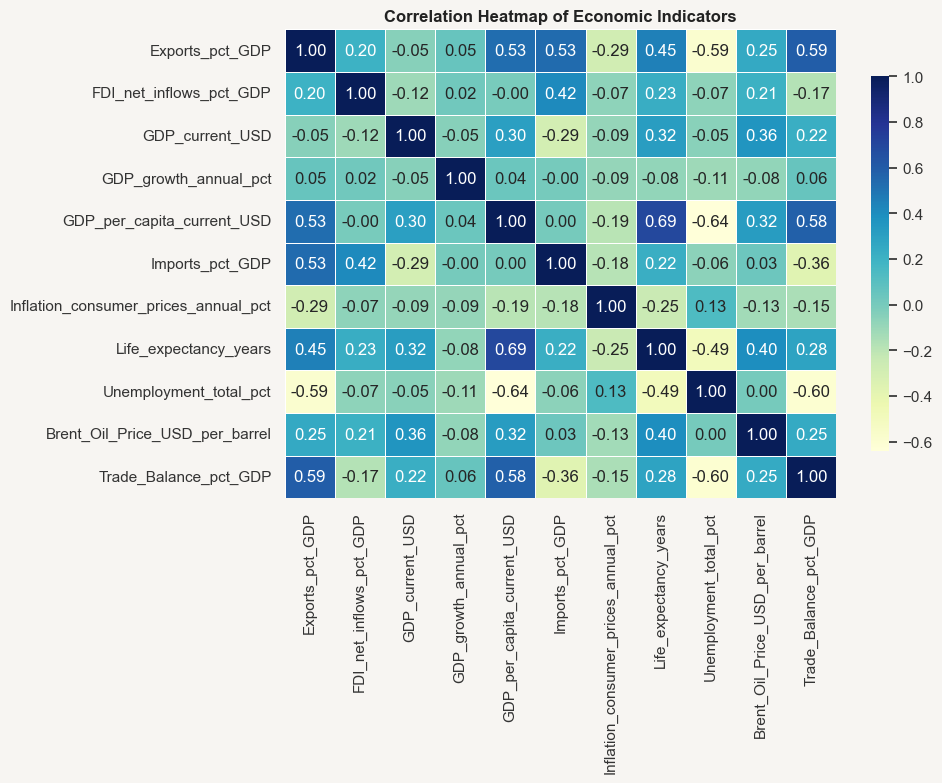

Correlation matrix (numeric indicators):


,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel,Trade_Balance_pct_GDP
Exports_pct_GDP,1.00,0.20,-0.05,0.05,0.53,0.53,-0.29,0.45,-0.59,0.25,0.59
FDI_net_inflows_pct_GDP,0.20,1.00,-0.12,0.02,-0.00,0.42,-0.07,0.23,-0.07,0.21,-0.17
GDP_current_USD,-0.05,-0.12,1.00,-0.05,0.30,-0.29,-0.09,0.32,-0.05,0.36,0.22
GDP_growth_annual_pct,0.05,0.02,-0.05,1.00,0.04,-0.00,-0.09,-0.08,-0.11,-0.08,0.06
GDP_per_capita_current_USD,0.53,-0.00,0.30,0.04,1.00,0.00,-0.19,0.69,-0.64,0.32,0.58
Imports_pct_GDP,0.53,0.42,-0.29,-0.00,0.00,1.00,-0.18,0.22,-0.06,0.03,-0.36
Inflation_consumer_prices_annual_pct,-0.29,-0.07,-0.09,-0.09,-0.19,-0.18,1.00,-0.25,0.13,-0.13,-0.15
Life_expectancy_years,0.45,0.23,0.32,-0.08,0.69,0.22,-0.25,1.00,-0.49,0.40,0.28
Unemployment_total_pct,-0.59,-0.07,-0.05,-0.11,-0.64,-0.06,0.13,-0.49,1.00,0.00,-0.60
Brent_Oil_Price_USD_per_barrel,0.25,0.21,0.36,-0.08,0.32,0.03,-0.13,0.40,0.00,1.00,0.25


In [15]:
# Build list of numeric columns to include in correlation
corr_cols = numeric_cols_existing.copy()
if "Trade_Balance_pct_GDP" in df.columns:
    corr_cols.append("Trade_Balance_pct_GDP")

corr_cols = [c for c in corr_cols if c in df.columns]

if corr_cols:
    corr_matrix = df[corr_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Correlation Heatmap of Economic Indicators")
    plt.show()

    print("Correlation matrix (numeric indicators):")
    display(corr_matrix)
else:
    print("No numeric columns available for correlation matrix.")

## 🔗 1️⃣1️⃣ Country-wise Clustering

We group countries into **clusters** based on:

- **Average GDP per capita**
- **Average exports/imports (% of GDP)**
- **Average unemployment**
- **Average inflation**
- A proxy for **oil dependency**:
  - Correlation between **GDP growth** and **Brent oil price** by country.

This helps identify:

- **Oil-sensitive economies**
- **More diversified economies**
- **Conflict-affected or volatile economies**

> Note: Clustering requires `scikit-learn`. If it is not installed, this section will print a message instead of raising an error.

In [16]:
if SKLEARN_AVAILABLE and {"Country", "Year"}.issubset(df.columns):
    features_list = []

    for country, grp in df.groupby("Country"):
        feat = {"Country": country}

        if "GDP_per_capita_current_USD" in grp.columns:
            feat["GDP_per_capita_mean"] = grp["GDP_per_capita_current_USD"].mean()

        if "Exports_pct_GDP" in grp.columns:
            feat["Exports_pct_GDP_mean"] = grp["Exports_pct_GDP"].mean()

        if "Imports_pct_GDP" in grp.columns:
            feat["Imports_pct_GDP_mean"] = grp["Imports_pct_GDP"].mean()

        if "Unemployment_total_pct" in grp.columns:
            feat["Unemployment_mean"] = grp["Unemployment_total_pct"].mean()

        if "Inflation_consumer_prices_annual_pct" in grp.columns:
            feat["Inflation_mean"] = grp["Inflation_consumer_prices_annual_pct"].mean()

        # Oil dependency proxy: correlation GDP growth vs Brent oil price
        if {"GDP_growth_annual_pct", OIL_COL}.issubset(grp.columns):
            grp_non_null = grp[["GDP_growth_annual_pct", OIL_COL]].dropna()
            if (
                not grp_non_null.empty
                and grp_non_null[OIL_COL].nunique() > 1
                and grp_non_null["GDP_growth_annual_pct"].nunique() > 1
            ):
                feat["Oil_GDP_Growth_corr"] = grp_non_null["GDP_growth_annual_pct"].corr(
                    grp_non_null[OIL_COL]
                )

        features_list.append(feat)

    country_features = pd.DataFrame(features_list).set_index("Country")

    # Drop columns that are entirely NaN and rows with any missing
    country_features = country_features.dropna(axis=1, how="all")
    country_features = country_features.dropna(axis=0, how="any")

    print("Feature matrix for clustering:")
    display(country_features)

    if country_features.shape[0] >= 3 and country_features.shape[1] >= 2:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(country_features)

        # Choose number of clusters (e.g., 3)
        k = 3
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_scaled)
        country_features["Cluster"] = clusters

        print("\nCountry clusters (k=3):")
        display(country_features)

        if PLOTLY_AVAILABLE:
            # Pick two main features for 2D visualization if available
            feat_x = (
                "GDP_per_capita_mean"
                if "GDP_per_capita_mean" in country_features.columns
                else country_features.columns[0]
            )
            feat_y = (
                "Exports_pct_GDP_mean"
                if "Exports_pct_GDP_mean" in country_features.columns
                else country_features.columns[1]
            )

            fig = px.scatter(
                country_features.reset_index(),
                x=feat_x,
                y=feat_y,
                color="Cluster",
                hover_name="Country",
                title="Country Clusters Based on Economic Structure & Oil Sensitivity",
            )
            fig.update_layout(
                xaxis_title=feat_x.replace("_", " "),
                yaxis_title=feat_y.replace("_", " "),
            )
            fig.show()
        else:
            print("\nCluster memberships:")
            for cl in sorted(country_features["Cluster"].unique()):
                members = country_features.index[country_features["Cluster"] == cl].tolist()
                print(f"Cluster {cl}: {', '.join(members)}")
    else:
        print("Not enough countries or features to perform clustering.")

elif not SKLEARN_AVAILABLE:
    print("scikit-learn is not installed. Install it to run the clustering analysis.")
else:
    print("Required columns for clustering are missing.")

Feature matrix for clustering:


,GDP_per_capita_mean,Exports_pct_GDP_mean,Imports_pct_GDP_mean,Unemployment_mean,Inflation_mean,Oil_GDP_Growth_corr
Country,,,,,,
Bahrain,"19,405.71",79.10,65.88,1.14,1.28,-0.11
Egypt,"1,998.25",20.14,26.42,9.76,11.19,-0.11
Iran,"3,779.25",22.42,21.70,10.93,22.43,-0.16
Iraq,"3,414.65",39.55,31.49,10.13,46.12,-0.14
Israel,"29,697.97",30.71,32.04,8.40,4.45,-0.28
Jordan,"2,804.25",45.19,69.06,15.36,3.58,-0.03
Kuwait,"29,030.26",54.66,39.54,1.63,3.14,-0.11
Lebanon,"5,120.61",22.64,55.84,8.98,44.36,-0.32
Oman,"15,350.13",50.57,35.99,3.75,2.03,0.10



Country clusters (k=3):


,GDP_per_capita_mean,Exports_pct_GDP_mean,Imports_pct_GDP_mean,Unemployment_mean,Inflation_mean,Oil_GDP_Growth_corr,Cluster
Country,,,,,,,
Bahrain,"19,405.71",79.10,65.88,1.14,1.28,-0.11,0
Egypt,"1,998.25",20.14,26.42,9.76,11.19,-0.11,1
Iran,"3,779.25",22.42,21.70,10.93,22.43,-0.16,1
Iraq,"3,414.65",39.55,31.49,10.13,46.12,-0.14,1
Israel,"29,697.97",30.71,32.04,8.40,4.45,-0.28,1
Jordan,"2,804.25",45.19,69.06,15.36,3.58,-0.03,1
Kuwait,"29,030.26",54.66,39.54,1.63,3.14,-0.11,2
Lebanon,"5,120.61",22.64,55.84,8.98,44.36,-0.32,1
Oman,"15,350.13",50.57,35.99,3.75,2.03,0.10,2


## ⚠️ 1️⃣2️⃣ Events & Anomaly Detection

We overlay major events:

- **1991** – Gulf War  
- **2008** – Global Financial Crisis  
- **2014** – Oil price crash  
- **2020** – COVID-19 oil collapse  

on regional macro indicators to see their impact on:

- **GDP growth**
- **Inflation**
- **FDI net inflows**
- **Unemployment**

We also detect **statistical anomalies** using simple **z-scores** (values far from their historical mean).

In [17]:
events = {
    1991: "Gulf War",
    2008: "Global Financial Crisis & Oil Spike",
    2014: "Oil Price Crash",
    2020: "COVID-19 & Oil Collapse",
}

def compute_z(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std(ddof=0)

indicators_for_events = [
    "GDP_growth_annual_pct",
    "Inflation_consumer_prices_annual_pct",
    "FDI_net_inflows_pct_GDP",
    "Unemployment_total_pct",
]

region_event_data = {}

if "Year" in df.columns:
    for col in indicators_for_events:
        if col in df.columns:
            region_series = (
                df.groupby("Year")[col]
                .mean()
                .reset_index()
                .rename(columns={col: "value"})
            )
            region_series["indicator"] = col
            region_event_data[col] = region_series

    # Example: GDP growth with event markers & anomaly detection
    if "GDP_growth_annual_pct" in region_event_data:
        gdp_ev = region_event_data["GDP_growth_annual_pct"].copy()
        gdp_ev["zscore"] = compute_z(gdp_ev["value"])

        anomalies = gdp_ev.loc[gdp_ev["zscore"].abs() >= 2, ["Year", "value", "zscore"]]
        print("GDP growth anomalies (|z| >= 2) at regional level:")
        display(anomalies)

        if PLOTLY_AVAILABLE:
            fig = px.line(
                gdp_ev,
                x="Year",
                y="value",
                title="Regional Average GDP Growth with Key Events & Anomalies",
            )
            for year, label in events.items():
                fig.add_vline(x=year, line_dash="dash", line_color="#9E2B25", opacity=0.7)
                fig.add_annotation(
                    x=year,
                    y=gdp_ev["value"].max(),
                    text=label,
                    showarrow=False,
                    yshift=10,
                    textangle=90,
                    font=dict(size=9, color="#9E2B25"),
                )
            # Highlight anomaly points
            anomaly_years = anomalies["Year"].tolist()
            fig.add_scatter(
                x=gdp_ev.loc[gdp_ev["Year"].isin(anomaly_years), "Year"],
                y=gdp_ev.loc[gdp_ev["Year"].isin(anomaly_years), "value"],
                mode="markers",
                marker=dict(color="#9E2B25", size=10, symbol="diamond"),
                name="Anomaly (|z| >= 2)",
            )
            fig.update_layout(yaxis_title="GDP Growth (annual %)")
            fig.show()
        else:
            plt.figure(figsize=(10, 6))
            plt.plot(gdp_ev["Year"], gdp_ev["value"], marker="o", color=COLOR_PALETTE[0])
            for year, label in events.items():
                plt.axvline(year, linestyle="--", color="#9E2B25", alpha=0.7)
                plt.text(
                    year + 0.1,
                    gdp_ev["value"].max(),
                    label,
                    rotation=90,
                    color="#9E2B25",
                    fontsize=8,
                    va="bottom",
                )
            # Mark anomalies
            plt.scatter(
                anomalies["Year"],
                anomalies["value"],
                color="#9E2B25",
                s=70,
                marker="D",
                label="Anomaly (|z| >= 2)",
            )
            plt.title("Regional Average GDP Growth with Key Events & Anomalies")
            plt.xlabel("Year")
            plt.ylabel("GDP Growth (annual %)")
            plt.legend()
            plt.show()

GDP growth anomalies (|z| >= 2) at regional level:


,Year,value,zscore
2,1992,15.71,3.17
30,2020,-4.89,-2.61


## 🔹 Summary

This notebook provided a **clean, themed, and structured** analysis of **Middle Eastern economies (1990–2024)** with a focus on **oil prices**:

- Confirmed a **balanced panel** of 13 countries and 1990–2024 coverage.
- Visualized **GDP growth, trade, inflation, FDI, unemployment, and life expectancy** in a consistent **light earth-tone theme**.
- Explored how **Brent oil price** correlates with:
  - GDP growth, exports, FDI, inflation, and unemployment.
- Identified **export-led vs import-heavy** economies using trade balance.
- Highlighted:
  - **Largest economies** by GDP.
  - **Fastest improvements** in life expectancy.
  - **Recession years** and **unemployment spikes**.
- Built a **correlation heatmap** showing key relationships across indicators.
- Performed **country clustering** (when `scikit-learn` is available) to group:
  - Oil-sensitive vs more diversified economies.
- Overlaid **major events** (1991, 2008, 2014, 2020) and detected **statistical anomalies** in regional GDP growth.

---
